In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:00


In [4]:
!cp -r /content/drive/MyDrive/custom_data /content/custom_data
print("✅ Copy done!")

✅ Copy done!


In [5]:
# Step 2 — Fix yaml to point to local path
import yaml

yaml_path = '/content/custom_data/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = '/content/custom_data'
data['train'] = 'train/images'
data['val']   = 'valid/images'
data['test']  = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print("✅ YAML updated!")

✅ YAML updated!


In [6]:
# Step 3 — Train locally (much faster)
!yolo detect train \
  data=/content/custom_data/data.yaml \
  model=yolo11s.pt \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  patience=15 \
  cache=True \
  project=/content/custom_data \
  name=my_model \
  exist_ok=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

In [7]:
!yolo detect val \
  model=/content/custom_data/my_model/weights/best.pt \
  data=/content/custom_data/data.yaml \
  split=test

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 20.5±9.4 MB/s, size: 177.7 KB)
val: Scanning /content/custom_data/test/labels... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 220.1it/s 0.4s
val: New cache created: /content/custom_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.2it/s 5.1s
                   all         91        720      0.954      0.954      0.971      0.764
            right-side         91        629      0.932       0.93      0.974      0.763
            wrong-side         84         91      0.976      0.978      0.968      0.765
Speed: 7.8ms preprocess, 9.6ms inference, 0.0ms loss, 6.7ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/mo

In [8]:
!yolo detect predict \
  model=/content/custom_data/my_model/weights/best.pt \
  source=/content/custom_data/test/images \
  save=True \
  conf=0.25 \
  project=/content/custom_data \
  name=predictions

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/91 /content/custom_data/test/images/wsd_10_mp4-0011_jpg.rf.fcd76aa14aa1351feb371ac7163b896f.jpg: 384x640 10 right-sides, 52.2ms
image 2/91 /content/custom_data/test/images/wsd_11_mp4-0006_jpg.rf.ede108e2dc0b462081142067582a6e85.jpg: 384x640 11 right-sides, 1 wrong-side, 8.2ms
image 3/91 /content/custom_data/test/images/wsd_11_mp4-0028_jpg.rf.07d382d028e5b0ab3f766a2fd68c19e4.jpg: 384x640 10 right-sides, 1 wrong-side, 8.2ms
image 4/91 /content/custom_data/test/images/wsd_11_mp4-0033_jpg.rf.fc3f29ccb57ae60e86181172170bf584.jpg: 384x640 7 right-sides, 1 wrong-side, 8.3ms
image 5/91 /content/custom_data/test/images/wsd_11_mp4-0036_jpg.rf.5c166457638ed09c8d48daef221f4480.jpg: 384x640 8 right-sides, 1 wrong-side, 8.1ms
image 6/91 /content/custom_data/test/images/wsd_11_mp4-0040_jpg.rf.4b68ec3f01a5a70462edb14ad293bd4f.jp

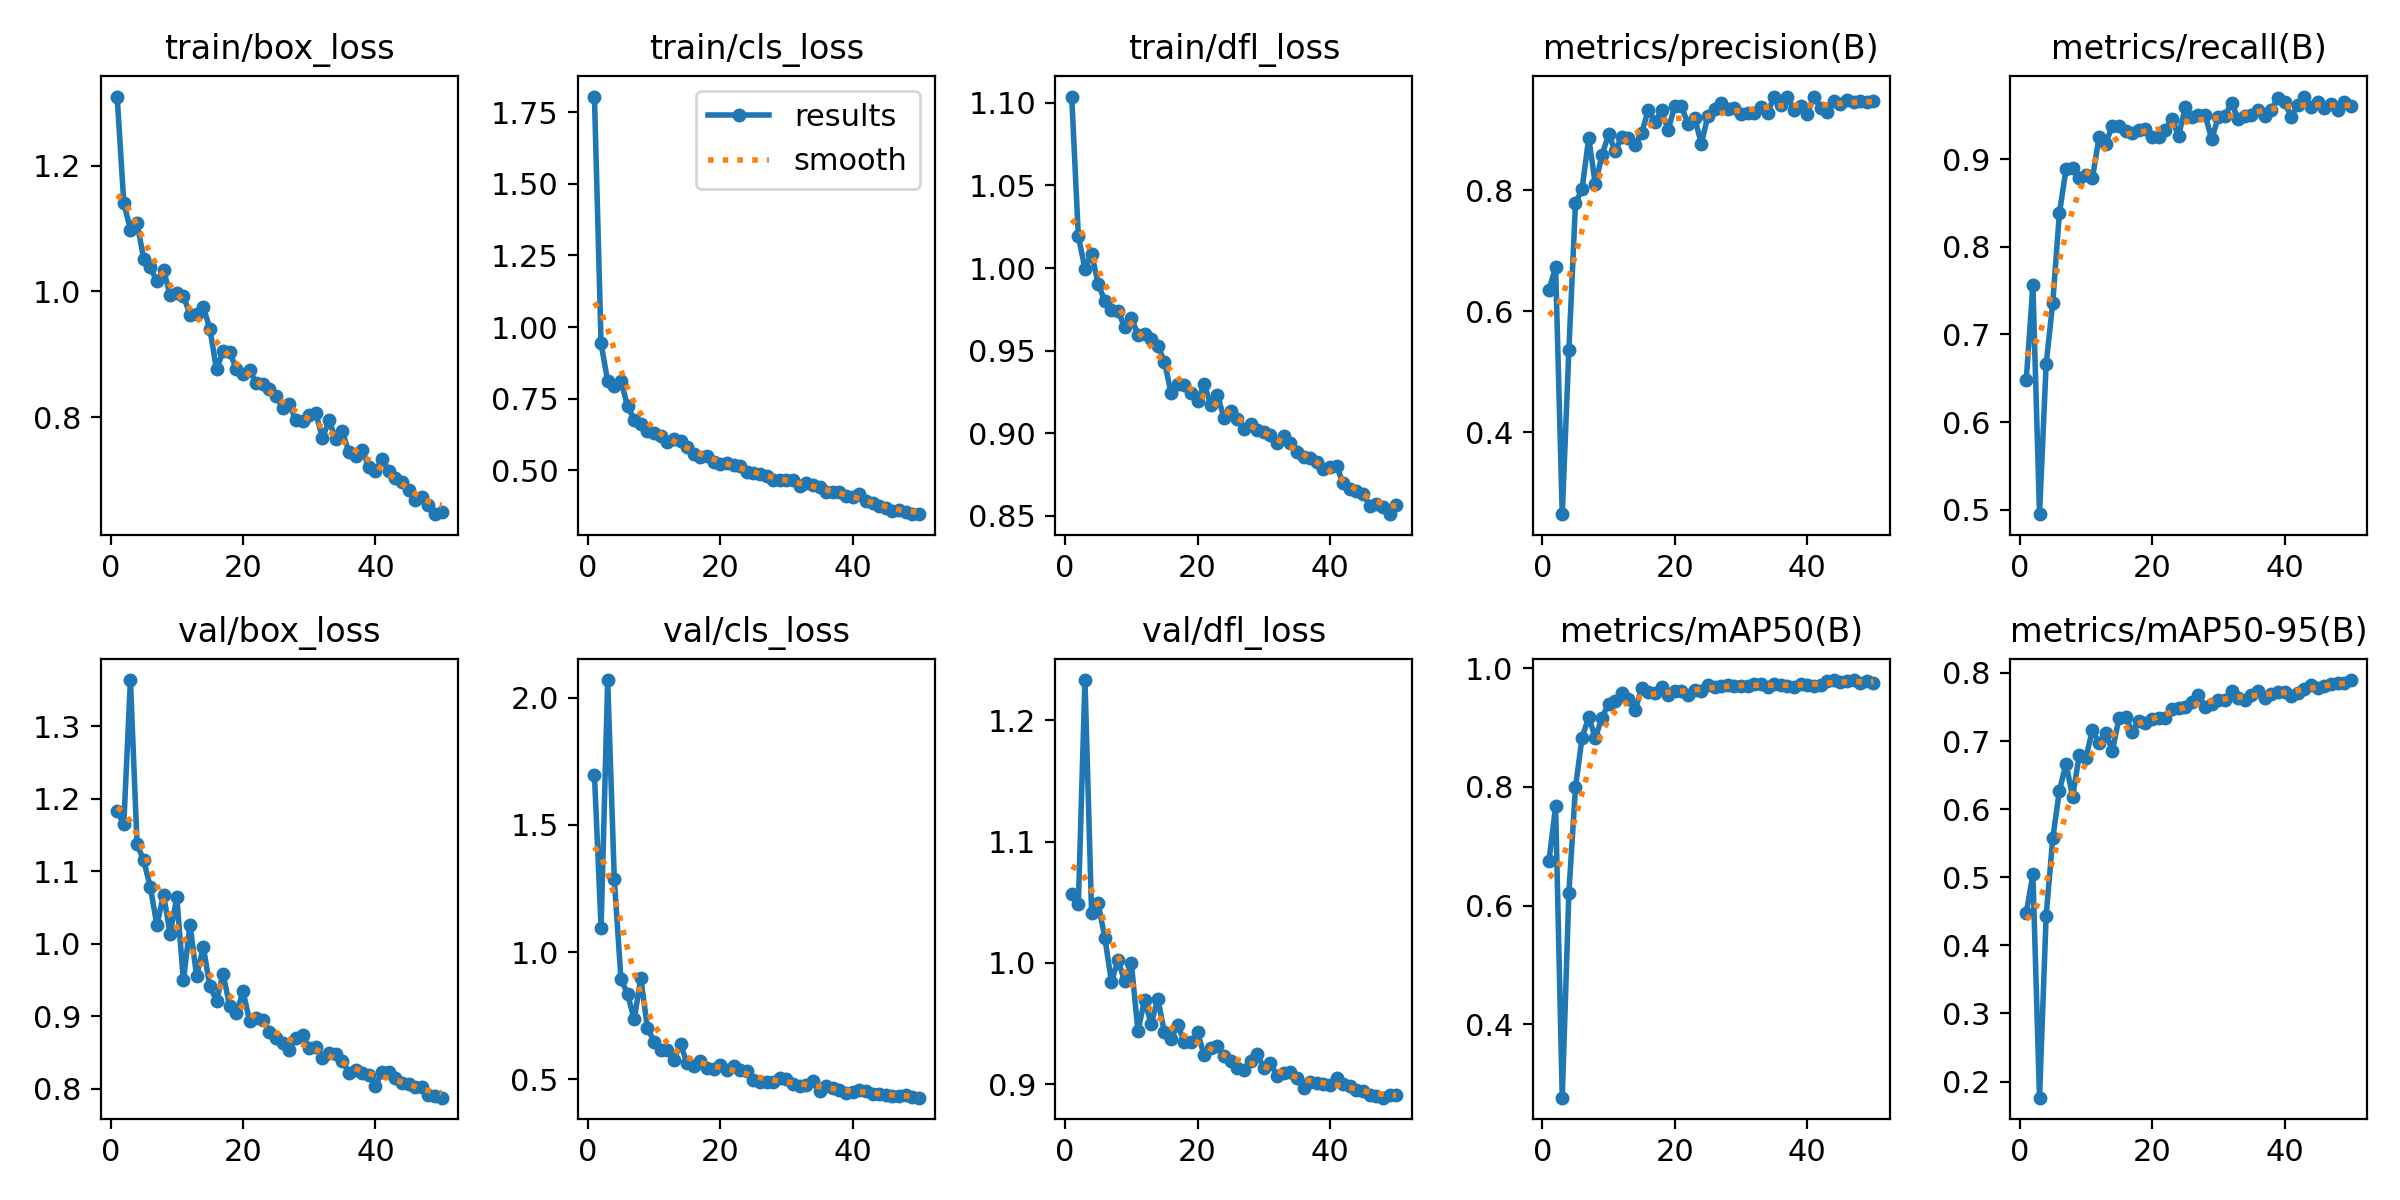

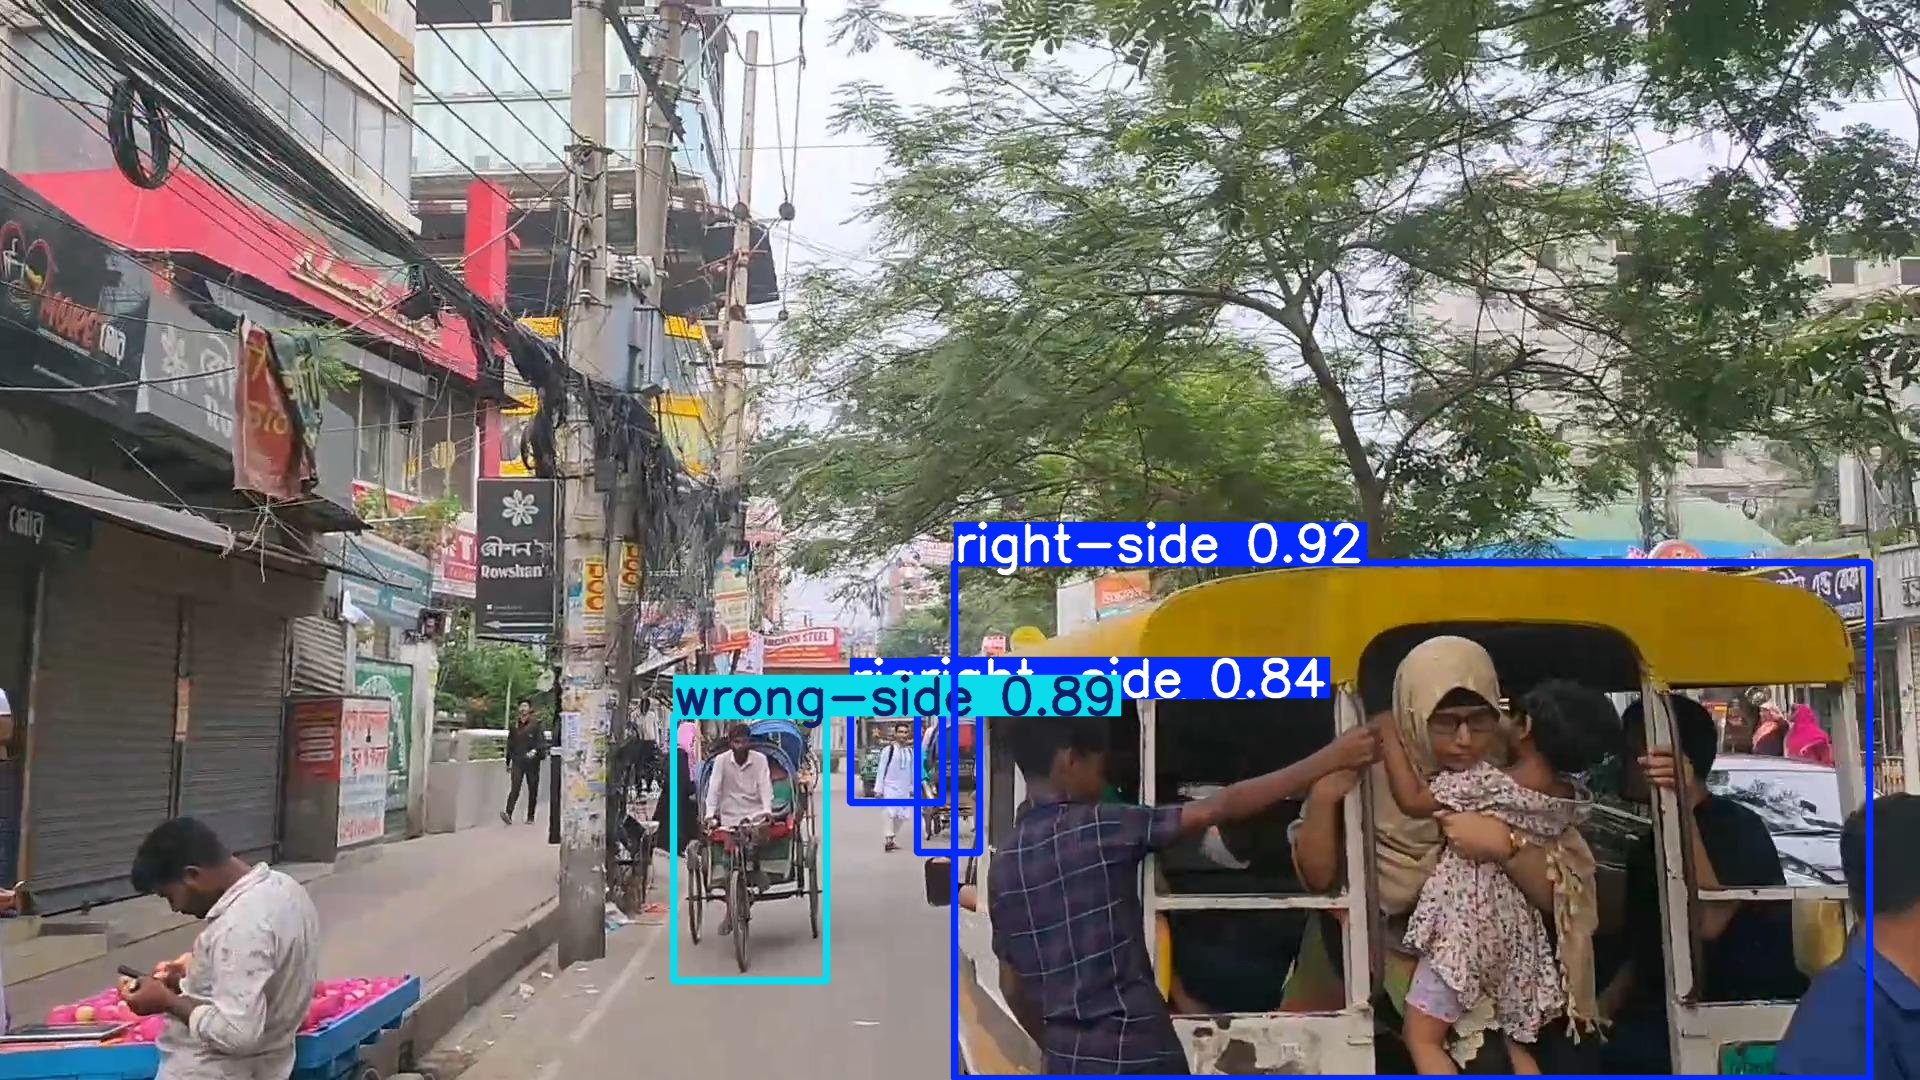

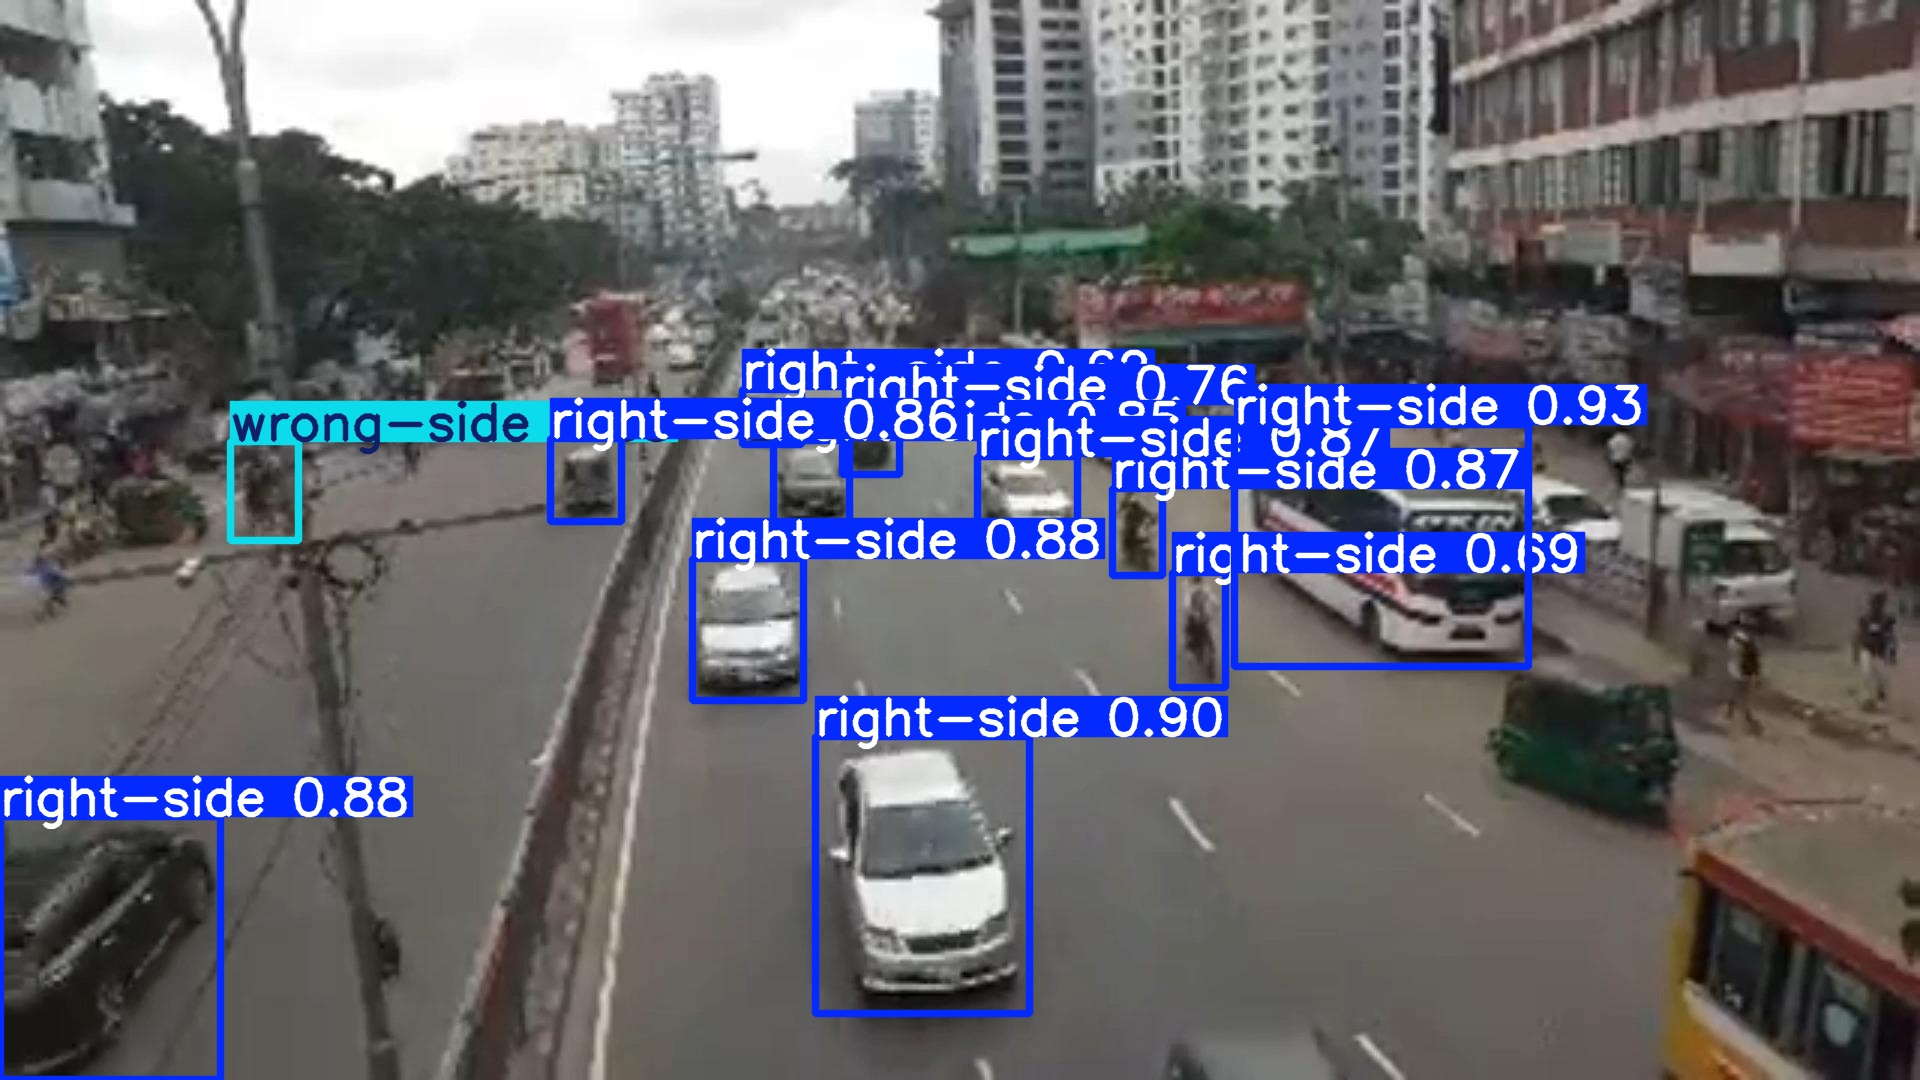

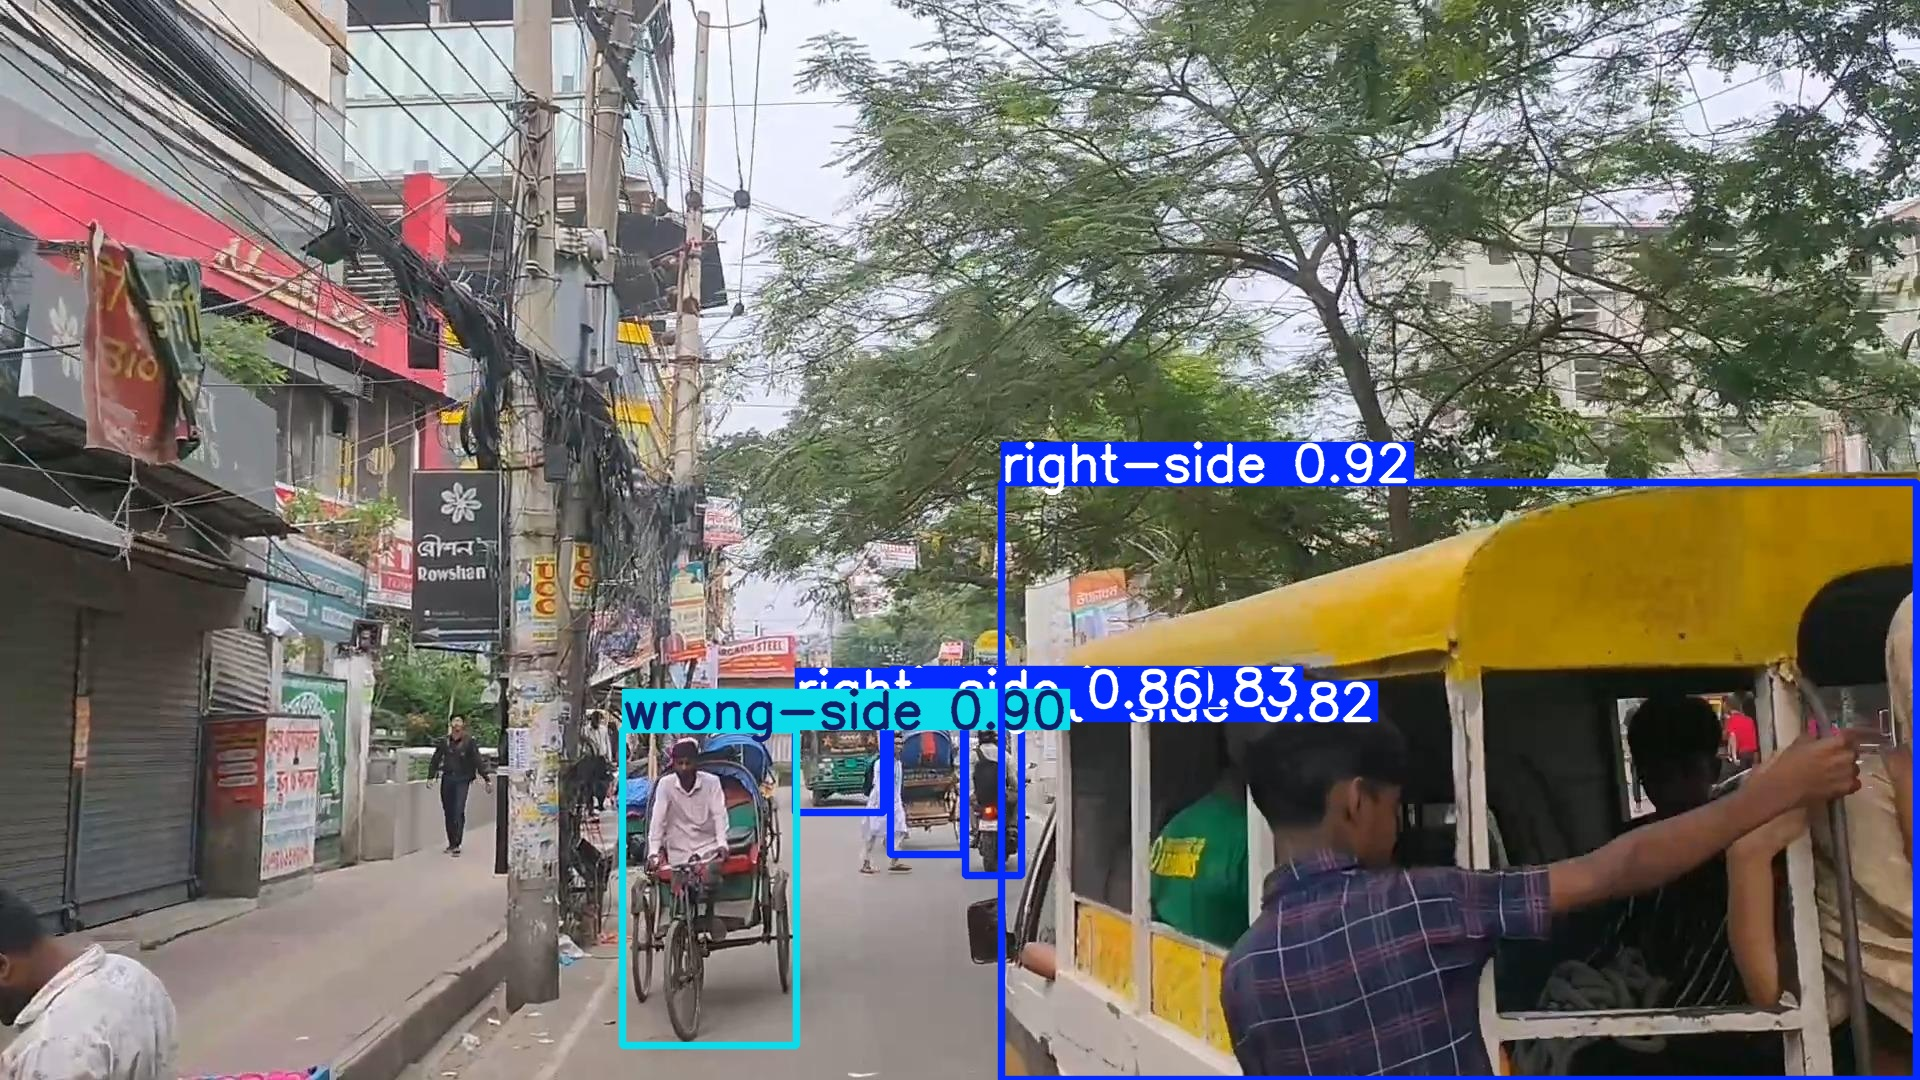

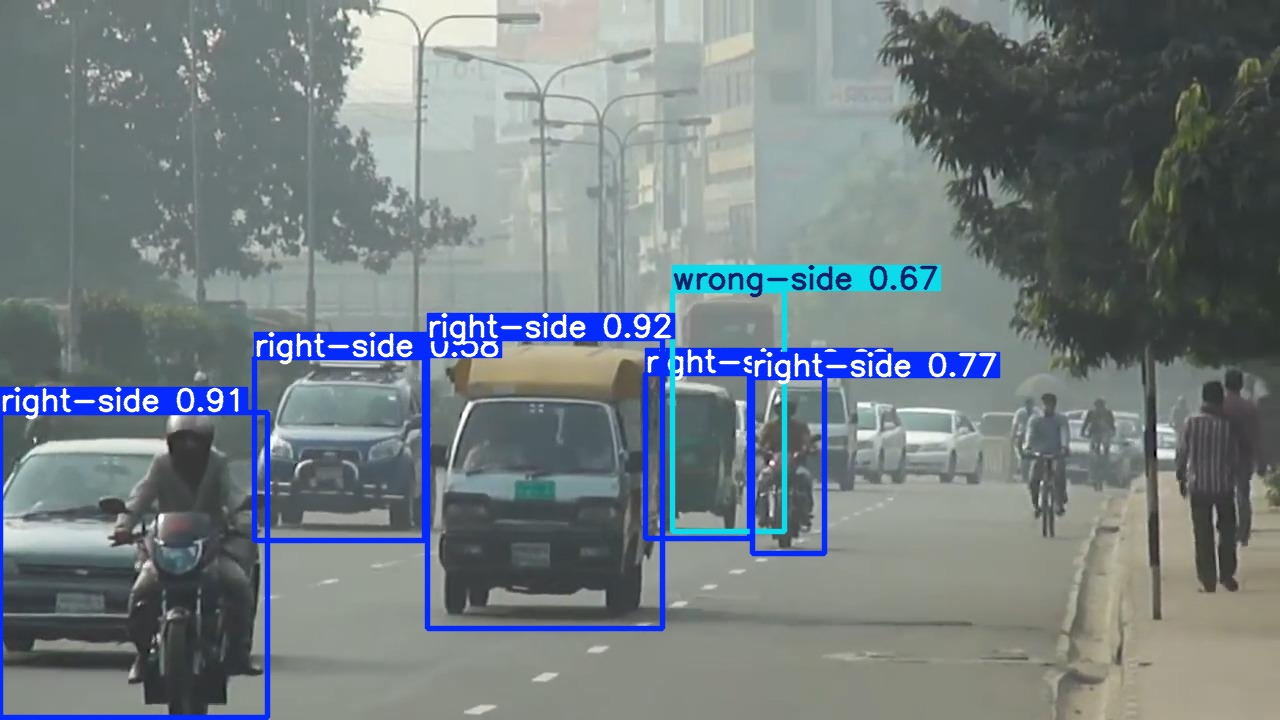

In [9]:
from IPython.display import Image, display
import glob

# Show training curves
display(Image('/content/custom_data/my_model/results.png'))

# Show a few predictions
pred_images = glob.glob('/content/custom_data/predictions/*.jpg')[:4]
for img in pred_images:
    display(Image(img, width=500))

In [10]:
from google.colab import files

# Download only best.pt (small, fast)
files.download('/content/custom_data/my_model/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test

In [17]:
from google.colab import files
from IPython.display import Image, display
import os

# Upload your images
uploaded = files.upload()

# Save uploaded files to a test folder
os.makedirs('/content/my_test_images', exist_ok=True)
for filename in uploaded.keys():
    os.rename(filename, f'/content/my_test_images/{filename}')

print(f"✅ Uploaded {len(uploaded)} image(s)")

Saving ckpijsb8_car_625x300_03_January_22.png to ckpijsb8_car_625x300_03_January_22.png
✅ Uploaded 1 image(s)


In [18]:
!yolo detect predict \
  model=/content/custom_data/my_model/weights/best.pt \
  source=/content/my_test_images \
  save=True \
  conf=0.25 \
  project=/content \
  name=my_test_results \
  exist_ok=True

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/3 /content/my_test_images/ckpijsb8_car_625x300_03_January_22.png: 448x640 1 right-side, 82.2ms
image 2/3 /content/my_test_images/download (6).png: 384x640 3 right-sides, 84.1ms
image 3/3 /content/my_test_images/download (7).png: 448x640 (no detections), 12.9ms
Speed: 3.0ms preprocess, 59.7ms inference, 8.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/my_test_results
💡 Learn more at https://docs.ultralytics.com/modes/predict


✅ Showing 3 result(s):

/content/my_test_results/download (6).jpg


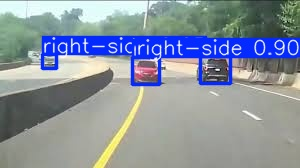

/content/my_test_results/ckpijsb8_car_625x300_03_January_22.jpg


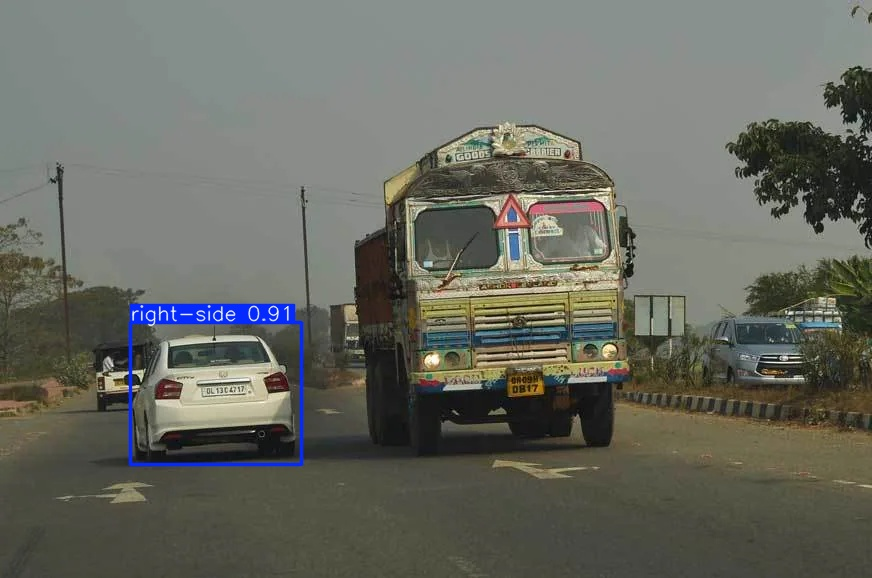

/content/my_test_results/download (7).jpg


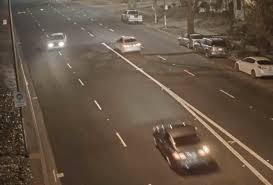

In [19]:
import glob
from IPython.display import Image, display

results = glob.glob('/content/my_test_results/*.jpg') + \
          glob.glob('/content/my_test_results/*.png')

if not results:
    print("❌ No results found — check if detection ran correctly")
else:
    print(f"✅ Showing {len(results)} result(s):\n")
    for img_path in results:
        print(img_path)
        display(Image(img_path, width=600))